In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision']
imports = {'pillow': 'PIL'}
pinned = {}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "5d733eab198ad58f23ceee3f1550014385366ece"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/5d733eab198ad58f23ceee3f1550014385366ece/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Policy Gradient

In the previous sections, we solved reinforcement learning problems by working with value functions: Value Iteration computed $V^*$ from a known MDP, and Q-Learning estimated $Q^*$ from data collected by the robot. In both cases the policy itself was obtained *indirectly*, by taking the action that maximizes the (action-)value function at each state. In this section we will look at a third approach, called the policy gradient method [@Williams.1992; @Sutton.McAllester.Singh.ea.2000], which learns the policy *directly*: we write the policy as a differentiable function of some parameters and adjust these parameters by gradient ascent on the average *return*. Like Q-Learning, this method does not require knowing the transition or reward functions of the MDP; the robot learns from the trajectories it collects itself.

## Parameterizing the Policy

Recall from that section that a stochastic policy $\pi(a \mid s)$ is a conditional distribution over actions. To learn a policy by gradient ascent, we first need to write this distribution as a differentiable function of some parameters $\theta$. A simple and effective choice for our gridworld is to keep one parameter $\theta_{s,a}$, called a preference, for every state-action pair, and to turn the preferences at state $s$ into probabilities using the softmax function

$$\pi_\theta(a \mid s) = \frac{e^{\theta_{s,a}}}{\sum_{a'} e^{\theta_{s,a'}}}.$$

This is the same softmax construction that we used for the exploration policy in that section, with one important difference: there, the quantities inside the exponentials were the estimated action values $\hat{Q}(s, a)$; here, the preferences $\theta_{s,a}$ are free parameters that we will adjust directly. Note that a softmax policy assigns a non-zero probability to every action at every state, so the robot automatically keeps exploring; we do not need a separate $\epsilon$-greedy mechanism.

The softmax policy is easy to differentiate. Since $\log \pi_\theta(a \mid s) = \theta_{s,a} - \log \sum_{a'} e^{\theta_{s,a'}}$, the derivative with respect to the preference $\theta_{s,b}$ of any action $b$ at the same state is

$$\frac{\partial \log \pi_\theta(a \mid s)}{\partial \theta_{s,b}} = \mathbb{1}_{b = a} - \pi_\theta(b \mid s),$$

and the derivative with respect to the preferences of every other state is zero. The quantity $\nabla_\theta \log \pi_\theta(a \mid s)$ is called the score function; we will see next why it plays the central role in this method.

## The Policy Gradient

### An Optimization Problem over Trajectories

Imagine, as in that section, that the robot starts at a state $s_0$ and takes actions from the policy $\pi_\theta$ for $T$ timesteps, producing a trajectory $\tau = (s_0, a_0, r_0, s_1, a_1, r_1, \ldots, s_T)$ with *return* $R(\tau) = \sum_{t=0}^{T-1} \gamma^t r(s_t, a_t)$. The probability of observing a particular trajectory $\tau$ is the product of the probabilities of each action taken by the robot and each transition made by the environment,

$$P(\tau; \theta) = \prod_{t=0}^{T-1} \pi_\theta(a_t \mid s_t)\ P(s_{t+1} \mid s_t, a_t).$$

If the start state were drawn from a distribution $\rho(s_0)$ instead of being fixed, a factor $\rho(s_0)$ would multiply this product; it does not depend on $\theta$ and drops out of every gradient below, so we keep the start state fixed as in our gridworld. Our objective is the average *return* over trajectories, which we now view as a function of the policy parameters,

$$J(\theta) = E_{\tau \sim P(\cdot;\, \theta)} \Big[ R(\tau) \Big] = \sum_{\tau} R(\tau)\ P(\tau; \theta),$$

where the summation runs over all possible trajectories of length $T$. Note that $J(\theta) = V^{\pi_\theta}(s_0)$ in the notation of that section (in our episodic gridworld every trajectory reaches a terminal state, after which all rewards are zero, so the finite sum agrees with the infinite-horizon *return*); the new point of view is that we can search for good parameters directly,

$$\max_\theta J(\theta) = \max_\theta \sum_{\tau} R(\tau)\ P(\tau; \theta).$$

### The Log-Derivative Trick

To maximize $J(\theta)$ by gradient ascent we need its gradient. The return $R(\tau)$ of a fixed trajectory does not depend on $\theta$, only the probability of the trajectory does, so (the summation is finite, so we can exchange it with the gradient)

$$
\begin{aligned}
\nabla_\theta J(\theta) &= \nabla_\theta \sum_\tau R(\tau)\ P(\tau; \theta) = \sum_\tau R(\tau)\ \nabla_\theta P(\tau; \theta) \\
&= \sum_\tau R(\tau)\ P(\tau; \theta)\ \frac{\nabla_\theta P(\tau; \theta)}{P(\tau; \theta)} \\
&= \sum_\tau P(\tau; \theta)\ R(\tau)\ \nabla_\theta \log P(\tau; \theta),
\end{aligned}
$$

where we multiplied and divided by $P(\tau; \theta)$ and used the identity $\nabla \log P = \nabla P / P$. This step, known as the log-derivative trick, is important because it turns the gradient back into an average over trajectories,

$$\nabla_\theta J(\theta) = E_{\tau \sim P(\cdot;\, \theta)} \Big[ R(\tau)\ \nabla_\theta \log P(\tau; \theta) \Big],$$

and averages over trajectories are exactly what the robot can estimate by sampling: it simply runs its current policy.

### The Transition Probabilities Drop Out

At first sight the equation still seems to require the MDP, because $P(\tau; \theta)$ in the equation contains the transition function. But watch what happens when we take the logarithm of the product and differentiate:

$$
\begin{aligned}
\nabla_\theta \log P(\tau; \theta) &= \nabla_\theta \Big[ \sum_{t=0}^{T-1} \log \pi_\theta(a_t \mid s_t) + \sum_{t=0}^{T-1} \log P(s_{t+1} \mid s_t, a_t) \Big] \\
&= \sum_{t=0}^{T-1} \nabla_\theta \log \pi_\theta(a_t \mid s_t).
\end{aligned}
$$

The transition probabilities do not depend on the policy parameters $\theta$, so their gradient is zero and they vanish from the expression. Just as in Q-Learning, we have not cheated: the transition function still determines *which* trajectories the robot is likely to experience, but we never need to evaluate it; it enters only implicitly, through the sampled data.

### The REINFORCE Estimator

We now approximate the expectation in the equation with an empirical average. The robot runs its current policy $\pi_\theta$ to collect $n$ trajectories $\tau_1, \ldots, \tau_n$ and computes

$$\hat{u} = \frac{1}{n} \sum_{i=1}^n R(\tau_i)\ \sum_{t=0}^{T-1} \nabla_\theta \log \pi_\theta(a_t^i \mid s_t^i),$$

which is an unbiased estimate of $\nabla_\theta J(\theta)$, and then takes a gradient ascent step $\theta \leftarrow \theta + \alpha \hat{u}$ with learning rate $\alpha$. This algorithm is known as REINFORCE [@Williams.1992]. It has a simple interpretation: each term pushes up the log-probability of the actions taken in trajectory $\tau_i$, scaled by the return of that trajectory. Trajectories with high *return* have the probability of their actions increased; trajectories with low *return* have them decreased. Note that after every parameter update the policy changes, so the robot must collect fresh trajectories from the new policy before the next update.

## Implementation of Policy Gradient

We now implement REINFORCE on FrozenLake from [Gymnasium](https://gymnasium.farama.org/), the same environment as in that section and that section: the robot moves on a $4 \times 4$ grid of hole (H), frozen (F) and goal (G) cells, all of which are unknown to the robot, transitions are deterministic, and the only reward is $1$ for reaching the goal. In each iteration the robot collects a batch of `batch_size` trajectories with its current policy and takes one gradient ascent step along the equation.

In [1]:

%matplotlib inline
import numpy as np
import random
from d2l import torch as d2l

seed = 0  # Random number generator seed
gamma = 0.95  # Discount factor
num_iters = 256  # Number of gradient ascent updates
batch_size = 16  # Trajectories sampled per update (n)
alpha = 2.0  # Learning rate
random.seed(seed)  # Set the random seed
np.random.seed(seed)

# Now set up the environment
env_info = d2l.make_env('FrozenLake-v1', seed=seed)

We first implement the softmax policy of the equation and a helper that runs one trajectory with the current parameters and records the visited states, the actions, and the discounted *return*:

In [2]:

def softmax_policy(theta, s):
    e = np.exp(theta[s] - np.max(theta[s]))
    return e / e.sum()

def sample_trajectory(env, theta, gamma):
    state, _ = env.reset()
    states, actions, rewards, done = [], [], [], False
    while not done:
        probs = softmax_policy(theta, state)
        action = np.random.choice(len(probs), p=probs)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        states.append(state)
        actions.append(action)
        rewards.append(reward)
        state = next_state
    R = 0.0  # Discounted return \sum_t gamma^t r_t via a backward pass
    for r in reversed(rewards):
        R = r + gamma * R
    return states, actions, R

We are now ready to implement REINFORCE. The gradient of the log-probability of one action is given by the equation: at the visited state, it is one-hot at the taken action minus the action probabilities.

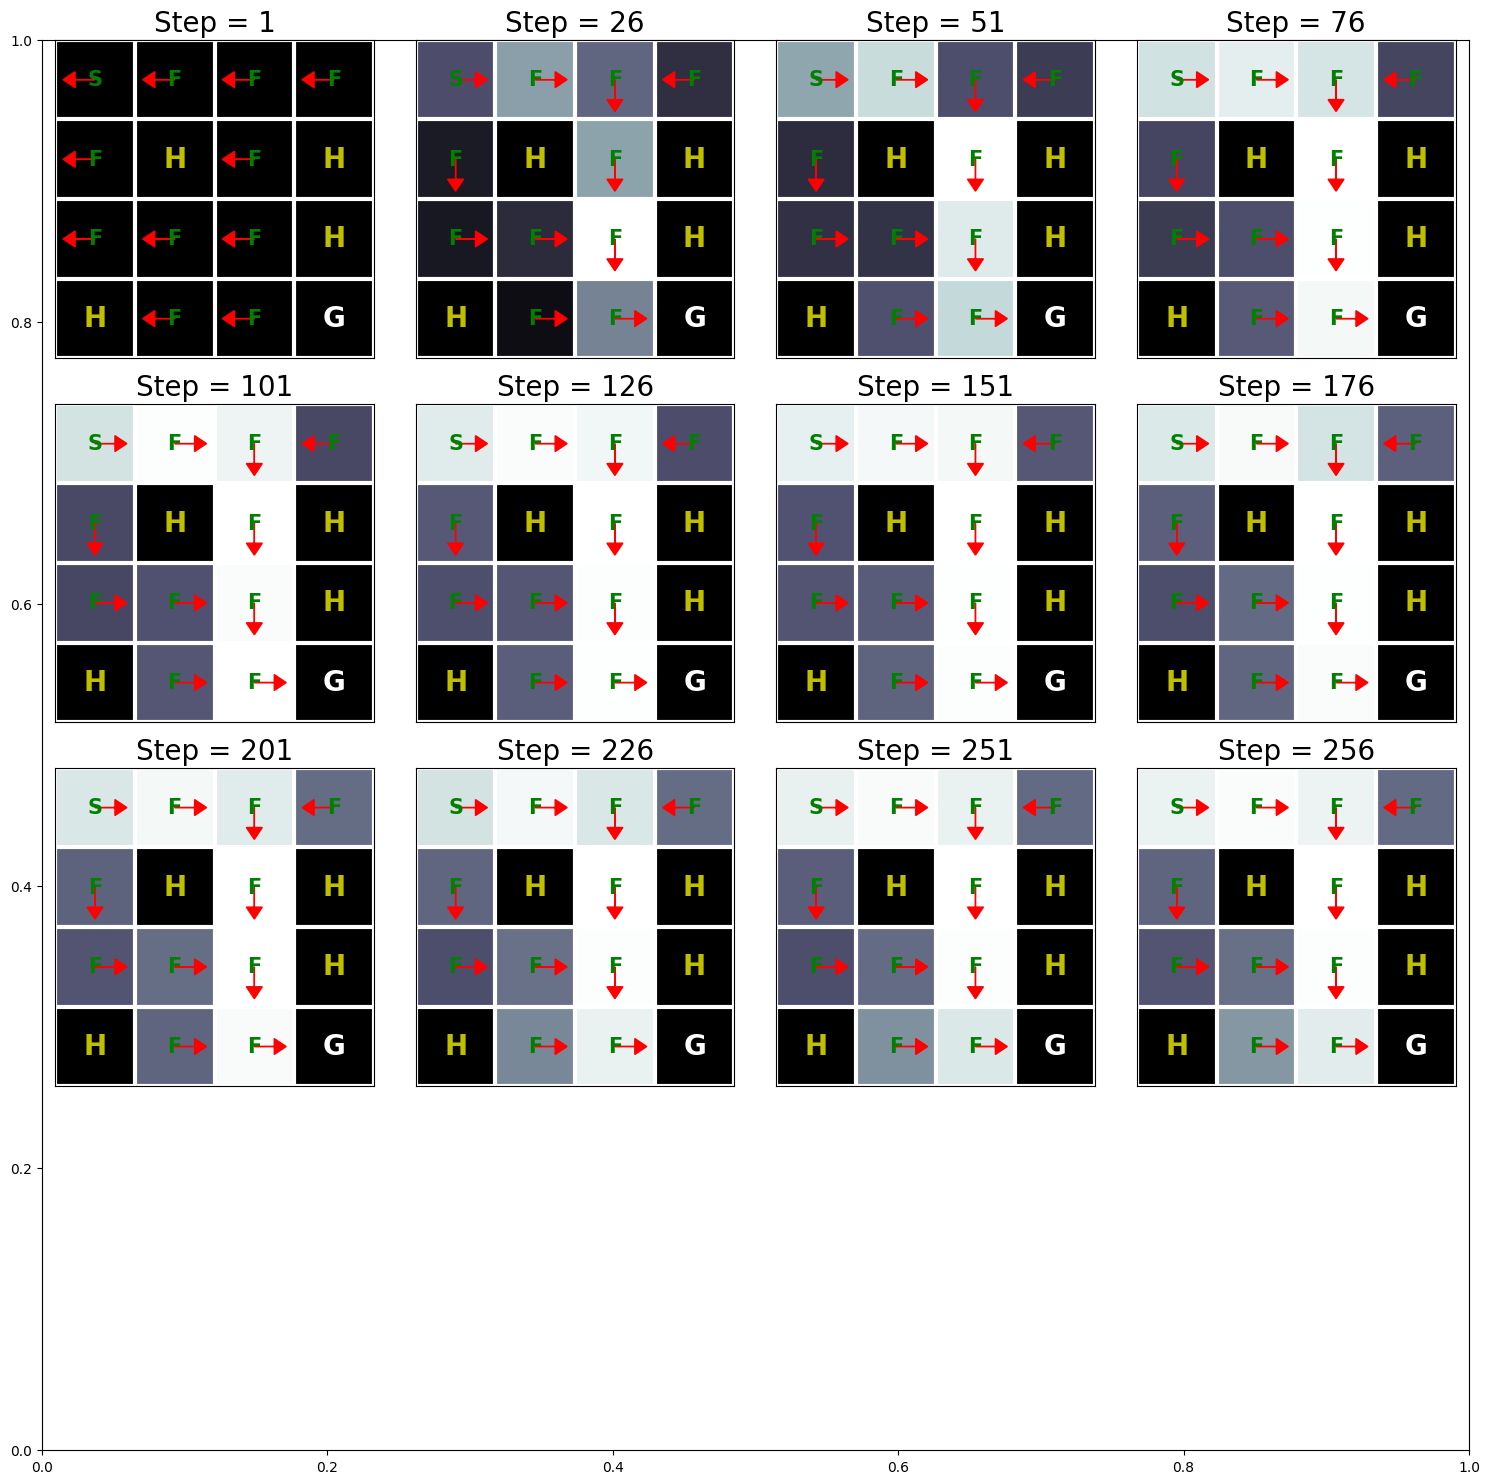

In [3]:

def reinforce(env_info, gamma, num_iters, batch_size, alpha):
    env_desc = env_info['desc']  # 2D array specifying what each grid item means
    env = env_info['env']  # The Gymnasium environment object
    num_states = env_info['num_states']
    num_actions = env_info['num_actions']

    theta = np.zeros((num_states, num_actions))  # Action preferences
    V  = np.zeros((num_iters + 1, num_states))
    pi = np.zeros((num_iters + 1, num_states))
    avg_returns = []  # Mean return of each batch: the estimate of J(theta)

    for k in range(1, num_iters + 1):
        # The REINFORCE estimator: average of R(tau) * sum_t grad log pi
        u = np.zeros_like(theta)
        batch_returns = []
        for _ in range(batch_size):
            states, actions, R = sample_trajectory(env, theta, gamma)
            batch_returns.append(R)
            # \sum_t grad log pi(a_t|s_t): one-hot(a_t) minus probabilities
            g = np.zeros_like(theta)
            for s, a in zip(states, actions):
                g[s] -= softmax_policy(theta, s)
                g[s, a] += 1.0
            u += R * g
        avg_returns.append(np.mean(batch_returns))
        # Gradient ascent step
        theta += alpha * u / batch_size
        # Record the policy for visualization purposes only: the color shows
        # the probability of the most likely action (0.25 = uniform, 1 = sure)
        for s in range(num_states):
            probs = softmax_policy(theta, s)
            V[k, s]  = np.max(probs)
            pi[k, s] = np.argmax(probs)
    d2l.show_Q_function_progress(env_desc, V[1:], pi[1:])
    return np.array(avg_returns)

avg_returns = reinforce(env_info=env_info, gamma=gamma, num_iters=num_iters,
                        batch_size=batch_size, alpha=alpha)

The visualization is read slightly differently than in the previous sections: the arrow still shows the most probable action at each state, but the color now shows the *probability* that the policy assigns to that action, from dark (near-uniform, $0.25$ with four actions) to light (near-certain). The policy sharpens along the same optimal path to the goal that Value Iteration and Q-Learning found. A trajectory that never reaches the goal has $R(\tau) = 0$ and contributes nothing to the equation, so early training crawls: until the robot stumbles into the goal by chance, every update is zero. In our run the average return of the batch does not stabilize until roughly update 75, as the learning curve below shows. The cells that stay at exactly $0.25$ in the plot are the holes and the goal: the robot never takes an action *from* a terminal state, so their preferences are never touched. The darker of the remaining cells are states visited mostly on failed trajectories, whose preferences have moved the least. The estimator is unbiased, but most of its samples say nothing at all; the next section is about fixing this.

Since the algorithm performs gradient ascent on $J(\theta)$, the most direct learning curve is $J(\theta)$ itself. The mean discounted return of each batch is exactly the Monte Carlo estimate of $J(\theta)$ computed from the same 16 trajectories that produced the update, so we get the curve for free:

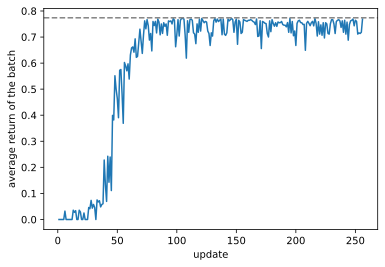

In [4]:

d2l.show_value_convergence(avg_returns, reference=gamma ** 5, xlabel='update',
                           ylabel='average return of the batch', marker=None)

The curve makes the two phases of the run visible. It hugs zero for the first stretch, since a batch without a single successful trajectory produces no update at all and the rare lucky batch barely moves it. It then climbs toward the dashed line at $\gamma^5 \approx 0.774$, the return of the optimal six-step path. It hovers slightly below that ceiling because the policy stays stochastic: any sampled action that deviates from the optimal path either lengthens the trajectory or ends it in a hole.

Notice also how much experience this took: each of the 256 updates consumed a fresh batch of 16 trajectories, i.e., 4096 episodes in total, compared to the 256 episodes of Q-Learning in that section. This is a structural property of the method, which we discuss next.

## On-Policy versus Off-Policy Learning

The REINFORCE estimator the equation is an average over trajectories drawn from the *current* policy $\pi_\theta$: it approximates the equation, an expectation under $P(\tau; \theta)$. As soon as the parameters are updated, trajectories collected earlier come from the wrong distribution and can no longer be used. Methods with this property are called *on-policy*: the robot learns only about the policy it is currently executing. On-policy methods are conceptually simple, but data hungry: every update needs fresh trajectories.

Q-Learning is different. Its update uses $\max_{a'} \hat{Q}(s', a')$ regardless of which action the robot actually took at $s'$, so it learns about the greedy policy while collecting data with a different, exploratory policy $\pi_e$. Methods of this kind are called *off-policy*: the robot can learn about one policy from data generated by another, and in particular can keep reusing old data. This makes off-policy methods far more sample efficient, but they come with their own difficulties in practice, typically requiring more careful hyper-parameter tuning and exhibiting stability issues, especially when combined with function approximation.

## Summary

Policy gradient methods learn the policy directly: the policy is written as a differentiable function of parameters, e.g., a softmax over per-state action preferences, and the parameters are updated by gradient ascent on the average return. The log-derivative trick turns the gradient of the objective into an expectation over trajectories, in which the transition probabilities cancel, so the method needs no knowledge of the MDP. The resulting REINFORCE estimator increases the probability of actions on high-return trajectories and decreases the probability of actions on low-return ones. The estimator is unbiased but noisy, and reducing its variance is the subject of the next section. Policy gradient methods are on-policy and therefore need fresh trajectories after every update, in contrast to off-policy methods like Q-Learning that can reuse data.

## Exercises

1. Try increasing the grid size to $8 \times 8$. Compared with the $4 \times 4$ grid, how many updates does it take to find a policy that reaches the goal?
1. Run the REINFORCE algorithm again with the discount factor $\gamma$ (i.e., `gamma` in the above code) set to $0$, $0.5$, and $1$, and analyze the results.
1. The derivative in the equation sums to zero over $b \in \mathcal{A}$. Verify this, and explain what it means for how a single update changes the preferences at one state.
1. Experiment with different values of `batch_size` and `alpha`. How does the batch size affect the noise in the learning process and the total number of episodes needed?